### **ICESat-2数据处理**

In [18]:
import h5py
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from astropy.time import Time
from pyrsimg import readTiff, imgShow


In [19]:
path_atl06 = 'data/icesat2/ATL06_20190821180402_08350402_006_02.h5'
path_rsimg = 'data/rsimg/setp_glacier_20200510_wgs84.tif'


In [20]:
# !h5ls $path_atl06
# !h5ls $path_atl06/gt1l/land_ice_segments
!h5ls $path_atl06/orbit_info


bounding_polygon_lat1    Dataset {25/Inf}
bounding_polygon_lon1    Dataset {25/Inf}
crossing_time            Dataset {1/Inf}
cycle_number             Dataset {1/Inf}
lan                      Dataset {1/Inf}
orbit_number             Dataset {1/Inf}
rgt                      Dataset {1/Inf}
sc_orient                Dataset {1/Inf}
sc_orient_time           Dataset {1/Inf}


In [21]:
def gps2dyr(gps_seconds):
    """ Convert from GPS seconds to decimal years. 
    args:
        gps_seconds: seconds start with reference gps time.
    """
    time_gps = Time(gps_seconds, format="gps")
    time_dyr = Time(time_gps, format="decimalyear").value
    return time_dyr



In [30]:
with h5py.File(path_atl06,'r') as setp_atl06:
    ## gt1l
    lat_gt1l = setp_atl06['gt1l/land_ice_segments/latitude'][:]
    lon_gt1l = setp_atl06['gt1l/land_ice_segments/longitude'][:]
    elev_gt1l = setp_atl06['gt1l/land_ice_segments/h_li'][:]
    time_delta_sdp = setp_atl06['gt1l/land_ice_segments/delta_time'][:] ## Seconds start with the reference sdp time(2018-01-01).
    ## delta time between the reference gps time (1980-01-01) and reference sdp time (2018-01-01). 
    time_delta_sdp_gps = setp_atl06['/ancillary_data/atlas_sdp_gps_epoch'][:] 
    ### quality
    qual_gt1l = setp_atl06['gt1l/land_ice_segments/atl06_quality_summary'][:]

    ## orbit information.
    cycle = setp_atl06['orbit_info/cycle_number'][0]
    track = setp_atl06['orbit_info/rgt'][0]
    orient = setp_atl06['orbit_info/sc_orient'][0]

## 2. remote sensing image
rsimg = readTiff(path_rsimg)


### Time conversion

In [31]:
seconds_gps = time_delta_sdp+time_delta_sdp_gps
seconds_gps
time_dyr = gps2dyr(seconds_gps)      # time in decimal years
time_dyr


array([2019.63768009, 2019.6376801 , 2019.6376801 , ..., 2019.63769585,
       2019.63769585, 2019.63769585])

### Data filtering

In [35]:
good_gt1l = qual_gt1l==0
lat_gt1l_filter, lon_gt1l_filter, elev_gt1l_filter = \
            lat_gt1l[good_gt1l], lon_gt1l[good_gt1l], elev_gt1l[good_gt1l]
print(lat_gt1l.shape)
print(lat_gt1l_filter.shape)

(80881,)
(49646,)


### Visualization

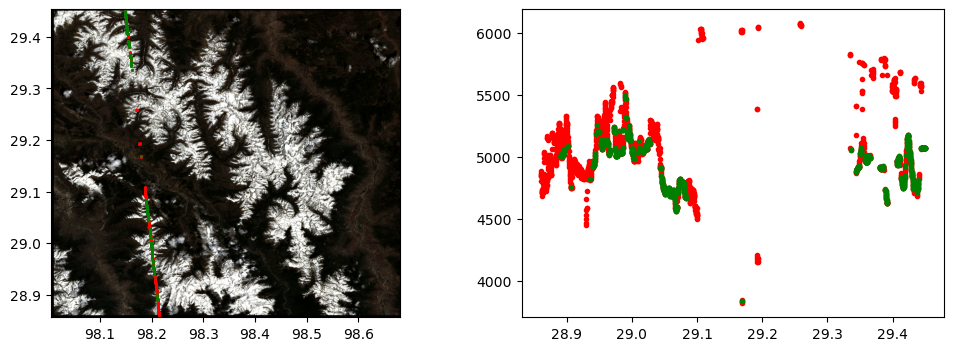

In [47]:
### gt1l
ids = np.where((lat_gt1l>28.86) & (lat_gt1l<29.45) & \
               (lon_gt1l>98) & (lon_gt1l<98.69) & (elev_gt1l<9000))
ids_filter = np.where((lat_gt1l_filter>28.86) & (lat_gt1l_filter<29.45) & \
                (lon_gt1l_filter>98) & (lon_gt1l_filter<98.69) & \
                (elev_gt1l_filter<9000))
fig, ax = plt.subplots(1,2, figsize=(12, 4))
imgShow(rsimg.array, extent=rsimg.geoextent, clip_percent=5, ax=ax[0])
ax[0].scatter(x=lon_gt1l[ids], y=lat_gt1l[ids], s=0.5, color='red')  
ax[0].scatter(x=lon_gt1l_filter[ids_filter], y=lat_gt1l_filter[ids_filter], s=0.5, color='green')
ax[1].plot(lat_gt1l[ids], elev_gt1l[ids], 'r.')
ax[1].plot(lat_gt1l_filter[ids_filter], elev_gt1l_filter[ids_filter], 'g.')
